# Support Vector Classfier

In [137]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [138]:
# synthetic datapoints
from sklearn.datasets import make_classification

X,y =make_classification(n_samples=200, n_features=2, n_redundant=0, n_classes=2, n_clusters_per_class=1, random_state=42)
X.shape, y.shape

((200, 2), (200,))

In [139]:
X[y == 0].shape, X[y == 1].shape


((100, 2), (100, 2))

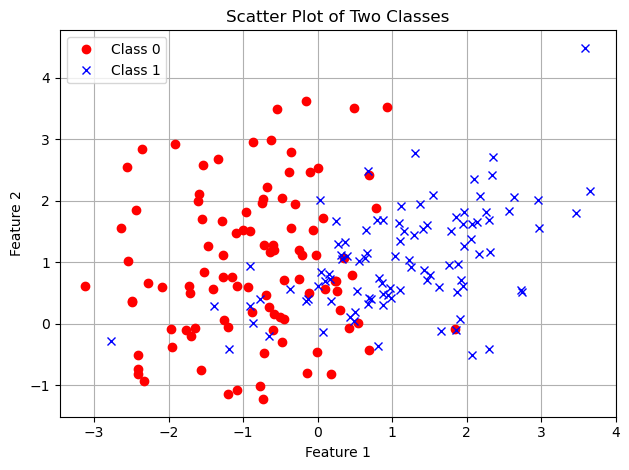

In [140]:
# Plotting the two classes separately using custom markers
# plt.figure(figsize=(6, 6))
plt.plot(X[y == 0][:, 0], X[y == 0][:, 1], "ro", label="Class 0")  # Red circles
plt.plot(X[y == 1][:, 0], X[y == 1][:, 1], "bx", label="Class 1")  # Blue crosses
# sns.scatterplot(X,y,hue=y) based ondataframe
plt.title("Scatter Plot of Two Classes")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
def plot_decision_boundary(clf, X_train, y_train, X_test, y_test):
    h = .02
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.6)

    # Training data
    plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], color='red', marker='o', label='Train Class 0')
    plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='blue', marker='x', label='Train Class 1')

    plt.title("Linear SVM with Train/Test Split")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [142]:
# # 4. Function to plot decision boundary
# def plot_decision_boundary(clf, X_train, y_train, X_test, y_test):
#     # Define the line range
#     x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
#     X_line = np.linspace(x_min, x_max, 100)

#     # Get weights and bias
#     w = clf.coef_[0]
#     b = clf.intercept_[0]

#     # Calculate the decision boundary line: w1*x + w2*y + b = 0 => y = -(w1*x + b)/w2
#     Y_line = -(w[0] * X_line + b) / w[1]

#     # Training data
#     plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], color='red', marker='o', label='Train Class 0')
#     plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='blue', marker='x', label='Train Class 1')

#     # Test data
#     plt.scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], edgecolor='black', facecolor='none', marker='o', s=80, label='Test Class 0')
#     plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], edgecolor='black', facecolor='none', marker='x', s=80, label='Test Class 1')

#     # Plot decision boundary
#     plt.plot(X_line, Y_line, 'k-', label='Decision Boundary')

#     plt.title("Linear SVM with Train/Test Split")
#     plt.xlabel("Feature 1")
#     plt.ylabel("Feature 2")
#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()


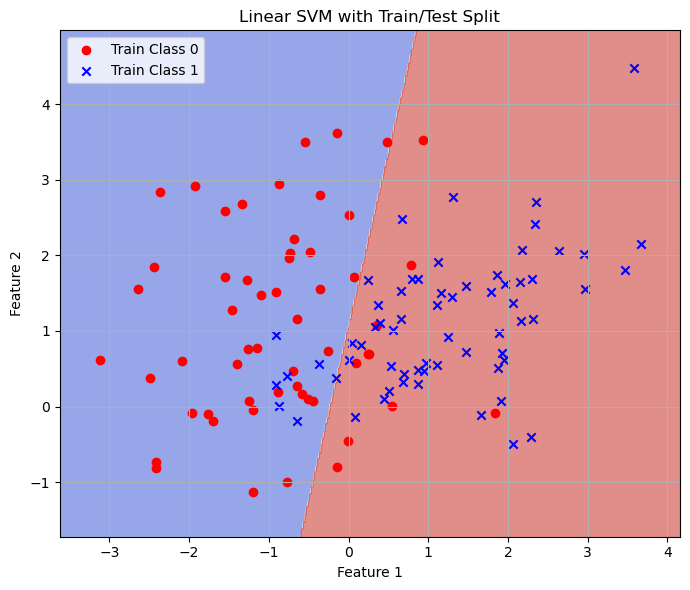

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# 2. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# 3. Train a linear SVM
svc = SVC(kernel="linear")
svc.fit(X_train, y_train)

# 5. Plot everything
plot_decision_boundary(svc, X_train, y_train, X_test, y_test)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predict on test set
y_pred = svc.predict(X_test)

# Print individual metrics
print("🔍 Evaluation Metrics on Test Set:")
print(f"Accuracy        : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision       : {precision_score(y_test, y_pred):.4f}")
print(f"Recall          : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score        : {f1_score(y_test, y_pred):.4f}")
print("\n📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred))


🔍 Evaluation Metrics on Test Set:
Accuracy        : 0.8500
Precision       : 0.8000
Recall          : 0.8889
F1 Score        : 0.8421

📊 Confusion Matrix:
[[36  8]
 [ 4 32]]

📄 Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        44
           1       0.80      0.89      0.84        36

    accuracy                           0.85        80
   macro avg       0.85      0.85      0.85        80
weighted avg       0.86      0.85      0.85        80



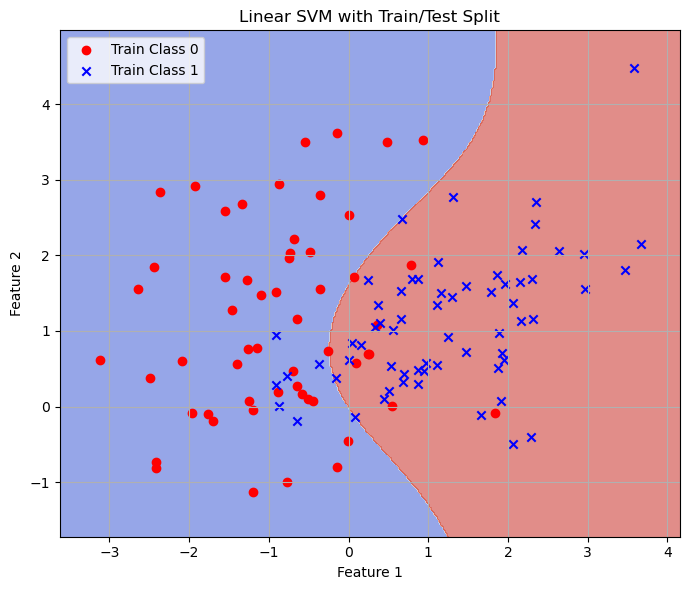

In [145]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# 2. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# 3. Train a linear SVM
svc = SVC(kernel="rbf")
svc.fit(X_train, y_train)

# 5. Plot everything
plot_decision_boundary(svc, X_train, y_train, X_test, y_test)


In [146]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predict on test set
y_pred = svc.predict(X_test)

# Print individual metrics
print("🔍 Evaluation Metrics on Test Set:")
print(f"Accuracy        : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision       : {precision_score(y_test, y_pred):.4f}")
print(f"Recall          : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score        : {f1_score(y_test, y_pred):.4f}")
print("\n📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred))


🔍 Evaluation Metrics on Test Set:
Accuracy        : 0.8500
Precision       : 0.8000
Recall          : 0.8889
F1 Score        : 0.8421

📊 Confusion Matrix:
[[36  8]
 [ 4 32]]

📄 Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        44
           1       0.80      0.89      0.84        36

    accuracy                           0.85        80
   macro avg       0.85      0.85      0.85        80
weighted avg       0.86      0.85      0.85        80



## Grid Search CV

In [147]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Define parameter grid for SVC
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4],       # Only used for 'poly' kernel
    'coef0': [0.0, 1.0]        # Used in 'poly' and 'sigmoid'
}

# Initialize GridSearchCV with SVC and 5-fold cross-validation
grid_search = GridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1, verbose=1)

# Fit on training data
grid_search.fit(X_train, y_train)

# Show the best parameters
print("✅ Best Parameters Found:")
print(grid_search.best_params_)

# Evaluate on test set
y_pred = grid_search.best_estimator_.predict(X_test)

print("\n📊 Classification Report on Test Data:")
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 108 candidates, totalling 540 fits
✅ Best Parameters Found:
{'C': 1, 'coef0': 1.0, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}

📊 Classification Report on Test Data:
              precision    recall  f1-score   support

           0       0.90      0.80      0.84        44
           1       0.78      0.89      0.83        36

    accuracy                           0.84        80
   macro avg       0.84      0.84      0.84        80
weighted avg       0.84      0.84      0.84        80

